# `hem_rect_fill` vs. `default_51`, by domain -- `chromatin_od`, 49 ROIs x 3 clicks

**Goal.** The 49-ROI pooled result for this pair (recorded in
`hem_rect_fill_vs_default_chromatin_od_49roi_3seed.ipynb`) showed a borderline gain for `hem_rect_fill`
that turned out to be driven almost entirely by one ROI (`291.tiff`), not a broad effect. This notebook
slices that same, already-verified run by domain to see whether the effect concentrates in particular
tissue types, is uniformly weak/absent, or whether that single-ROI mechanism recurs elsewhere.

**Data source.** No new pipeline run. This notebook loads the recorded outputs of
`hem_rect_fill_vs_default_chromatin_od_49roi_3seed.ipynb`
(`results/precision_at_k_49roi_3seed_chromatin_hemrectfill_*.csv`), independently re-derives the
per-ROI and per-domain numbers from the rawest recorded table (`per_run`), and cross-checks every
re-derived number against the recorded `per_roi`/`delta_per_roi`/`delta_stats` files before using them.
**Only** the plain `hem_rect_fill` arm is used here -- not `hem_rect_fill_1um`
(`hem_rect_fill_1um_margin_vs_default_chromatin_od_49roi_3seed.ipynb`), a different experiment (a 1 um
margin added to the kept rectangle).

**Design.** 49 ROIs split evenly across 7 domains, 7 ROIs each (2 from `original_14`, 5 from
`testing_35`), 3 clicks per ROI. ROI is the unit; the delta is `hem_rect_fill - default_51` TP@K summed
over the ROI's 3 clicks, same as the parent notebook.

**Per-domain statistics.** For each domain and K: pooled precision per arm, the pooled delta, ROI-level
W/L/T, an exact sign-flip p, a domain-specific cluster-bootstrap 95% CI (resampling that domain's own 7
ROIs, `N_BOOT` = 10,000), and a t interval over the 7 ROI-level deltas. Holm adjusts the exact p
**within each K, across the 7 domains** (family size 7) -- the multiple-comparison exposure this
breakdown introduces beyond the parent notebook's own family. A domain-level bar mirrors the parent
notebook's D5 bar: bootstrap CI excludes 0 **and** the same-direction ROIs are a majority of the
domain's 7 (i.e. >= 4).

**Outlier sensitivity.** For every domain and K, the single ROI with the largest-magnitude delta is
identified and the domain's pooled delta is recomputed with that one ROI left out. This is the same
check that found `291.tiff` driving the 49-ROI result, applied systematically instead of by eyeballing
one domain.

**Reading rules, fixed before the numbers below were read.**
- **Bootstrap CI excludes 0, delta > 0:** `hem_rect_fill` has higher precision than `default_51` in that domain, at that K.
- **Bootstrap CI excludes 0, delta < 0:** `default_51` has higher precision.
- **CI includes 0:** no difference detected. The CI is quoted as a bound, not as an effect.
- A CI that excludes 0 is read together with its Holm p and W/L/T, never on its own.

**Caveats.**
- n = 7 ROIs per domain. The exact sign-flip test's finest resolution with 7 nonzero deltas is
  p = 2/2^7 = 0.0156; with fewer nonzero ROIs (common here, given how tie-heavy TP@K deltas are) the
  floor is higher still. Bootstrap and t intervals at this n are wide -- treat every CI here as a wide
  bound, not a precise estimate.
- `chromatin_od` ranking only, inherited clicks, inherited fill rule -- same caveats as the parent
  notebook.
- This notebook does not re-verify the underlying template/detection pipeline; that gate already ran in
  the parent notebook (147/147 clicks reproduced, `od` bit-exact on 4410/4410 rows) and is not repeated
  here. What this notebook verifies is that its own domain-level arithmetic is a faithful, correctly
  labelled slice of that recorded run.

In [1]:
import math
import sys
from fractions import Fraction

import numpy as np
import pandas as pd
from scipy import stats as sps
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

sys.path.insert(0, '..')

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 400)
pd.set_option('display.max_colwidth', 140)

ARMS = ('default_51', 'hem_rect_fill')  # every delta is hem_rect_fill - default_51
BUDGETS = (10, 20, 30)
N_BOOT = 10_000
BOOT_SEED = 20260917  # the parent notebook's seed; reused for the all-49 reproduction check in Cell 5
HRF = '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill'
OUT = {
    'delta_stats': '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_by_domain_delta_stats.csv',
    'precision': '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_by_domain_precision.csv',
    'sensitivity': '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_by_domain_sensitivity.csv',
}
FIG_PATHS = {
    'forest': 'hemrectfill_by_domain_forest.png',
    'strip': 'hemrectfill_by_domain_roi_strip.png',
    'bars': 'hemrectfill_by_domain_precision_bars.png',
}

# validated reference palette (dataviz skill, references/palette.md): categorical slots 1-2, diverging blue<->red, neutral gray, chrome
BLUE, ORANGE, RED, GRAY = '#2a78d6', '#eb6834', '#e34948', '#898781'
INK, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#e1e0d9', '#fcfcfb'

print(f"arms {ARMS}; K = {BUDGETS}; cluster bootstrap B = {N_BOOT} (seed {BOOT_SEED})")
print('outputs:', *OUT.values(), *FIG_PATHS.values(), sep='\n  ')

arms ('default_51', 'hem_rect_fill'); K = (10, 20, 30); cluster bootstrap B = 10000 (seed 20260917)
outputs:
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_by_domain_delta_stats.csv
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_by_domain_precision.csv
  ../results/precision_at_k_49roi_3seed_chromatin_hemrectfill_by_domain_sensitivity.csv
  hemrectfill_by_domain_forest.png
  hemrectfill_by_domain_roi_strip.png
  hemrectfill_by_domain_precision_bars.png


In [2]:
PER_RUN = pd.read_csv(f'{HRF}_per_run.csv', float_precision='round_trip')
PER_ROI_REC = pd.read_csv(f'{HRF}_per_roi.csv', float_precision='round_trip')
DELTA_REC = pd.read_csv(f'{HRF}_delta_per_roi.csv', float_precision='round_trip')
STATS_REC = pd.read_csv(f'{HRF}_delta_stats.csv', float_precision='round_trip')

assert (len(PER_RUN), len(PER_ROI_REC), len(DELTA_REC), len(STATS_REC)) == (294, 98, 147, 3), 'a recorded hemrectfill file does not have its expected row count'
assert set(PER_RUN['condition'].unique()) == set(ARMS), f"unexpected conditions in per_run: {sorted(PER_RUN['condition'].unique())}"
assert PER_RUN.groupby('condition')['file_name'].nunique().eq(49).all(), '49 ROIs per arm expected'

DOMAIN_ROIS = PER_RUN[PER_RUN['condition'] == 'default_51'].groupby('domain')['file_name'].nunique()
assert len(DOMAIN_ROIS) == 7 and (DOMAIN_ROIS == 7).all(), f'expected 7 domains x 7 ROIs, got:\n{DOMAIN_ROIS}'
DOMAINS = sorted(DOMAIN_ROIS.index)

SUBSET_SPLIT = PER_RUN[PER_RUN['condition'] == 'default_51'].groupby(['domain', 'subset'])['file_name'].nunique().unstack('subset')
assert (SUBSET_SPLIT['original_14'] == 2).all() and (SUBSET_SPLIT['testing_35'] == 5).all(), f'expected 2 original_14 + 5 testing_35 per domain:\n{SUBSET_SPLIT}'

print(f'{len(PER_RUN)} per_run rows, {PER_RUN["file_name"].nunique()} ROIs, {len(DOMAINS)} domains x 7 ROIs each (2 original_14 + 5 testing_35):')
print(DOMAINS)

294 per_run rows, 49 ROIs, 7 domains x 7 ROIs each (2 original_14 + 5 testing_35):
['canine cutaneous mast cell tumor', 'canine lung cancer', 'canine lymphosarcoma', 'canine soft tissue sarcoma', 'human breast cancer', 'human melanoma', 'human neuroendocrine tumor']


In [3]:
PER_ROI = PER_RUN.groupby(['subset', 'domain', 'file_name', 'condition'], sort=False).agg(n_clicks=('seed_index', 'nunique'), **{f'tp_at_{k}': (f'tp_at_{k}', 'sum') for k in BUDGETS}).reset_index()
assert len(PER_ROI) == len(ARMS) * 49 and (PER_ROI['n_clicks'] == 3).all(), 'per_roi must hold every ROI x arm, each over 3 clicks'
for k in BUDGETS:
    PER_ROI[f'precision_at_{k}'] = PER_ROI[f'tp_at_{k}'] / (3 * k)

PER_ROI_KEY = ['subset', 'domain', 'file_name', 'condition']
merged = PER_ROI.merge(PER_ROI_REC, on=PER_ROI_KEY, suffixes=('_recomputed', '_recorded'), validate='one_to_one')
for k in BUDGETS:
    assert (merged[f'tp_at_{k}_recomputed'] == merged[f'tp_at_{k}_recorded']).all(), f'tp_at_{k} recomputed from per_run does not match the recorded per_roi.csv'
    assert np.isclose(merged[f'precision_at_{k}_recomputed'], merged[f'precision_at_{k}_recorded'], rtol=1e-12).all(), f'precision_at_{k} recomputed does not match recorded'
print(f'per_roi recomputed from per_run.csv matches the recorded per_roi.csv exactly on all {len(merged)} (ROI, arm) rows, every K')

wide = PER_ROI.pivot(index=['subset', 'domain', 'file_name'], columns='condition', values=[f'tp_at_{k}' for k in BUDGETS])
delta_parts = []
for k in BUDGETS:
    part = (wide[f'tp_at_{k}']['hem_rect_fill'] - wide[f'tp_at_{k}']['default_51']).rename('delta_tp_sum').reset_index()
    part['K'] = k
    delta_parts.append(part)
DELTA_RECOMPUTED = pd.concat(delta_parts, ignore_index=True)
assert len(DELTA_RECOMPUTED) == 147, f'{len(DELTA_RECOMPUTED)} delta rows, expected 147'

DELTA_KEY = ['subset', 'domain', 'file_name', 'K']
merged_d = DELTA_RECOMPUTED.merge(DELTA_REC, on=DELTA_KEY, suffixes=('_recomputed', ''), validate='one_to_one')
assert (merged_d['delta_tp_sum_recomputed'] == merged_d['delta_tp_sum']).all(), 'delta_tp_sum recomputed from per_run does not match the recorded delta_per_roi.csv'
print(f'delta_per_roi recomputed from per_run.csv matches the recorded delta_per_roi.csv exactly on all {len(merged_d)} (ROI, K) rows')

DELTA = DELTA_REC  # the check above proves this recorded file is an exact, faithful derivation of per_run.csv; use it directly from here on

per_roi recomputed from per_run.csv matches the recorded per_roi.csv exactly on all 98 (ROI, arm) rows, every K
delta_per_roi recomputed from per_run.csv matches the recorded delta_per_roi.csv exactly on all 147 (ROI, K) rows


In [4]:
def sign_flip_null_counts(abs_deltas):
    """
        Exact null distribution of sum(+/-|d_i|) by convolution over integer offsets.

        abs_deltas (array-like): nonzero absolute integer deltas, one per ROI.

        Returns np.ndarray: int64 counts of each sum -T..T (index = sum + T, T = sum |d_i|), totalling 2 ** n.
    """
    d = [int(v) for v in abs_deltas]
    assert all(v > 0 for v in d) and len(d) <= 62, 'nonzero integer deltas only, and 2 ** n must fit int64'
    total = sum(d)
    counts = np.zeros(2 * total + 1, dtype=np.int64)
    counts[total] = 1
    for v in d:
        shifted = np.zeros_like(counts)
        shifted[v:] += counts[:len(counts) - v]
        shifted[:len(counts) - v] += counts[v:]
        counts = shifted
    return counts


def exact_sign_flip_p(deltas):
    """
        Two-sided exact sign-flip p on integer per-ROI deltas, by dynamic-programming convolution.

        deltas (array-like): one integer delta per ROI; zeros carry no sign.

        Returns tuple[float, int]: the p-value (an exact rational converted to float), and the number of nonzero deltas.
    """
    d = np.asarray(deltas)
    assert np.all(d == np.round(d)), 'the convolution needs integer deltas'
    d = d.astype(np.int64)
    nz = np.abs(d[d != 0])
    if len(nz) == 0:
        return 1.0, 0
    counts = sign_flip_null_counts(nz)
    total = int(nz.sum())
    observed = abs(int(d.sum()))
    sums = np.arange(-total, total + 1)
    return float(Fraction(int(counts[np.abs(sums) >= observed].sum()), 2 ** len(nz))), len(nz)


def brute_force_sign_flip_p(deltas):
    """
        Two-sided sign-flip p by enumerating every sign pattern, kept only to validate the convolution.

        deltas (array-like): one delta per ROI; zeros carry no sign and are dropped.

        Returns float: the p-value.
    """
    import itertools
    d = np.asarray(deltas, dtype=np.float64)
    nz = np.abs(d[np.abs(d) > 1e-12])
    if len(nz) == 0:
        return 1.0
    signs = np.array(list(itertools.product([1.0, -1.0], repeat=len(nz))))
    return float((np.abs(signs @ nz) >= abs(float(d.sum())) - 1e-9).mean())


def holm_adjust(pvalues):
    """
        Holm step-down adjusted p-values, valid under any dependence between the tests.

        pvalues (array-like): raw p-values of one family of tests.

        Returns np.ndarray: adjusted p-values, in the input order.
    """
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]).clip(max=1.0)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


def boot_ci_exact(int_values, idx, denominator):
    """
        Percentile 95% CI of a pooled ratio over resampled ROIs, from exact integer numerators.

        int_values (np.ndarray): one integer numerator per ROI (a TP sum or a per-ROI TP delta).
        idx (np.ndarray): (n_boot, n_roi) resampled ROI indices.
        denominator (int): the pooled denominator per resample (n_roi x clicks per ROI x K).

        Returns tuple[float, float]: CI low, CI high, as fractions (not points).
    """
    sums = np.asarray(int_values, dtype=np.int64)[idx].sum(axis=1)
    lo, hi = np.percentile(sums / denominator, [2.5, 97.5])
    return float(lo), float(hi)


def pair_stats(d, n_roi, k, boot_idx):
    """
        Every paired statistic for one group (all ROIs or one domain) at one K, from its per-ROI TP deltas. All precision fields are fractions, not points.

        d (np.ndarray): one integer hem_rect_fill - default_51 TP@K delta per ROI, in a fixed ROI order.
        n_roi (int): number of ROIs in this group.
        k (int): the budget K.
        boot_idx (np.ndarray): (N_BOOT, n_roi) resampled ROI indices for this group, indexing into d's own order.

        Returns dict: n_roi, delta_tp_sum, pooled_delta_precision, wins, losses, ties, n_nonzero, exact_p, ci_low, ci_high, t_ci_low, t_ci_high, ci_excludes_0, t_ci_excludes_0, n_same_direction, majority, bar_met.
    """
    pooled_delta_precision = d.sum() / (3 * n_roi * k)
    wins, losses, ties = int((d > 0).sum()), int((d < 0).sum()), int((d == 0).sum())
    exact_p, n_nonzero = exact_sign_flip_p(d)
    ci_low, ci_high = boot_ci_exact(d, boot_idx, 3 * n_roi * k)
    x = d / (3 * k)
    if n_roi > 1 and x.std(ddof=1) > 0:
        half = sps.t.ppf(0.975, n_roi - 1) * x.std(ddof=1) / math.sqrt(n_roi)
        t_ci_low, t_ci_high = float(x.mean() - half), float(x.mean() + half)
    else:
        t_ci_low = t_ci_high = pooled_delta_precision
    ci_excludes_0 = bool(ci_low > 0 or ci_high < 0)
    t_ci_excludes_0 = bool(t_ci_low > 0 or t_ci_high < 0)
    n_same_direction = wins if pooled_delta_precision > 0 else (losses if pooled_delta_precision < 0 else 0)
    majority = bool(n_same_direction > n_roi / 2)
    return dict(n_roi=n_roi, delta_tp_sum=int(d.sum()), pooled_delta_precision=pooled_delta_precision, wins=wins, losses=losses, ties=ties, n_nonzero=n_nonzero, exact_p=exact_p, ci_low=ci_low, ci_high=ci_high, t_ci_low=t_ci_low, t_ci_high=t_ci_high, ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, n_same_direction=n_same_direction, majority=majority, bar_met=bool(ci_excludes_0 and majority))


check_rng = np.random.default_rng(0)
for n in range(1, 13):
    for _ in range(20):
        dd = check_rng.integers(-6, 7, size=n)
        assert exact_sign_flip_p(dd)[0] == brute_force_sign_flip_p(dd), f'convolution != enumeration on {dd}'
print('convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)')

convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)


In [5]:
# reproduce the recorded 49-ROI delta_stats.csv with pair_stats(), as a correctness gate before trusting the (unverified) domain slices below.
# same BOOT_IDX scheme and ROI row order as the parent notebook, verified above to give a bit-exact bootstrap CI.
BOOT_IDX_49 = np.random.default_rng([BOOT_SEED, 0]).integers(49, size=(N_BOOT, 49))

check_rows = []
for k in BUDGETS:
    d = DELTA.loc[DELTA['K'] == k, 'delta_tp_sum'].to_numpy()
    assert len(d) == 49, f'K={k}: {len(d)} ROIs, expected 49'
    check_rows.append(dict(K=k, **pair_stats(d, 49, k, BOOT_IDX_49)))
CHECK_49 = pd.DataFrame(check_rows)
CHECK_49['holm_p'] = holm_adjust(CHECK_49['exact_p'])

cmp = CHECK_49.merge(STATS_REC, on='K', suffixes=('_recomputed', '_recorded'))
for col in ('pooled_delta_precision', 'ci_low', 'ci_high', 't_ci_low', 't_ci_high', 'exact_p', 'holm_p'):
    assert np.allclose(cmp[f'{col}_recomputed'], cmp[f'{col}_recorded'], rtol=1e-9, atol=1e-12), f'{col} does not reproduce the recorded delta_stats.csv'
for col in ('wins', 'losses', 'ties', 'n_nonzero'):
    assert (cmp[f'{col}_recomputed'] == cmp[f'{col}_recorded']).all(), f'{col} does not reproduce the recorded delta_stats.csv'
for col in ('ci_excludes_0', 't_ci_excludes_0'):
    assert (cmp[f'{col}_recomputed'] == cmp[f'{col}_recorded']).all(), f'{col} does not reproduce the recorded delta_stats.csv'
assert (cmp['majority'] == cmp['majority_of_all_rois']).all() and (cmp['bar_met'] == cmp['d5_bar_met']).all(), 'majority/bar_met do not reproduce the recorded delta_stats.csv'

print('pair_stats() reproduces the recorded 49-ROI delta_stats.csv bit-for-bit: pooled_delta_precision, both CIs, wins/losses/ties, exact_p and holm_p at every K.')
print('this validates the stats code before it is applied to the domain slices below, which have no recorded reference to check against.')
disp = CHECK_49.copy()
for c in ('pooled_delta_precision', 'ci_low', 'ci_high', 't_ci_low', 't_ci_high'):
    disp[c] = disp[c] * 100
print(disp[['K', 'pooled_delta_precision', 'ci_low', 'ci_high', 't_ci_low', 't_ci_high', 'wins', 'losses', 'ties', 'exact_p', 'holm_p']].to_string(index=False, float_format=lambda v: f'{v:.4f}'))

pair_stats() reproduces the recorded 49-ROI delta_stats.csv bit-for-bit: pooled_delta_precision, both CIs, wins/losses/ties, exact_p and holm_p at every K.
this validates the stats code before it is applied to the domain slices below, which have no recorded reference to check against.
 K  pooled_delta_precision  ci_low  ci_high  t_ci_low  t_ci_high  wins  losses  ties  exact_p  holm_p
10                  0.2041 -1.0884   1.5646   -1.1416     1.5497    10       9    30   0.8457  1.0000
20                  0.4762 -0.5102   1.7007   -0.6592     1.6116    19      16    14   0.5047  1.0000
30                  0.9297  0.0454   2.0408   -0.0928     1.9522    20      14    15   0.0619  0.1858


In [6]:
DOMAIN_PREC = PER_ROI.groupby(['domain', 'condition']).agg(n_roi=('file_name', 'nunique'), **{f'tp_at_{k}': (f'tp_at_{k}', 'sum') for k in BUDGETS}).reset_index()
assert (DOMAIN_PREC['n_roi'] == 7).all()
for k in BUDGETS:
    DOMAIN_PREC[f'precision_at_{k}'] = DOMAIN_PREC[f'tp_at_{k}'] / (3 * DOMAIN_PREC['n_roi'] * k)
DOMAIN_PREC.to_csv(OUT['precision'], index=False)

print('pooled precision per arm, per domain (TP sum / (7 ROIs x 3 clicks x K)):')
print(DOMAIN_PREC[['domain', 'condition', 'n_roi'] + [f'tp_at_{k}' for k in BUDGETS] + [f'precision_at_{k}' for k in BUDGETS]].to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f"-> {OUT['precision']}")

pooled precision per arm, per domain (TP sum / (7 ROIs x 3 clicks x K)):
                          domain     condition  n_roi  tp_at_10  tp_at_20  tp_at_30  precision_at_10  precision_at_20  precision_at_30
canine cutaneous mast cell tumor    default_51      7       149       261       347           0.7095           0.6214           0.5508
canine cutaneous mast cell tumor hem_rect_fill      7       151       259       353           0.7190           0.6167           0.5603
              canine lung cancer    default_51      7        72       118       145           0.3429           0.2810           0.2302
              canine lung cancer hem_rect_fill      7        75       123       157           0.3571           0.2929           0.2492
            canine lymphosarcoma    default_51      7       111       230       328           0.5286           0.5476           0.5206
            canine lymphosarcoma hem_rect_fill      7       113       242       350           0.5381           0.5762

In [7]:
domain_rows = []
for di, dom in enumerate(DOMAINS):
    boot_idx = np.random.default_rng([BOOT_SEED, 1, di]).integers(7, size=(N_BOOT, 7))
    for k in BUDGETS:
        d = DELTA.loc[(DELTA['domain'] == dom) & (DELTA['K'] == k), 'delta_tp_sum'].to_numpy()
        assert len(d) == 7, f'{dom} K={k}: {len(d)} ROIs, expected 7'
        domain_rows.append(dict(domain=dom, K=k, **pair_stats(d, 7, k, boot_idx)))
DOMAIN_STATS = pd.DataFrame(domain_rows)

# Holm within each K, across the 7 domains -- the multiple-comparison family this breakdown introduces
DOMAIN_STATS['holm_p'] = DOMAIN_STATS.groupby('K')['exact_p'].transform(lambda s: pd.Series(holm_adjust(s.to_numpy()), index=s.index))
DOMAIN_STATS.to_csv(OUT['delta_stats'], index=False)

DISPLAY_COLS = ['domain', 'delta_tp_sum', 'pooled_delta_precision', 'wins', 'losses', 'ties', 'exact_p', 'holm_p', 'ci_low', 'ci_high', 't_ci_low', 't_ci_high', 'ci_excludes_0', 'majority', 'bar_met']
for k in BUDGETS:
    print(f'--- K={k} (pooled_delta_precision, ci_low/hi, t_ci_low/hi in points) ---')
    sub = DOMAIN_STATS[DOMAIN_STATS['K'] == k].copy()
    for c in ('pooled_delta_precision', 'ci_low', 'ci_high', 't_ci_low', 't_ci_high'):
        sub[c] = sub[c] * 100
    print(sub[DISPLAY_COLS].to_string(index=False, float_format=lambda v: f'{v:.3f}'))
    print()
print(f"-> {OUT['delta_stats']}")

--- K=10 (pooled_delta_precision, ci_low/hi, t_ci_low/hi in points) ---
                          domain  delta_tp_sum  pooled_delta_precision  wins  losses  ties  exact_p  holm_p  ci_low  ci_high  t_ci_low  t_ci_high  ci_excludes_0  majority  bar_met
canine cutaneous mast cell tumor             2                   0.952     2       0     5    0.500   1.000   0.000    2.381    -0.552      2.457          False     False    False
              canine lung cancer             3                   1.429     3       1     3    0.625   1.000  -1.905    4.762    -3.232      6.089          False     False    False
            canine lymphosarcoma             2                   0.952     3       2     2    0.875   1.000  -6.667    9.048    -9.534     11.439          False     False    False
      canine soft tissue sarcoma            -1                  -0.476     1       2     4    1.000   1.000  -1.905    0.952    -2.604      1.651          False     False    False
             human breast ca

In [8]:
sens_rows = []
for dom in DOMAINS:
    for k in BUDGETS:
        sub = DELTA[(DELTA['domain'] == dom) & (DELTA['K'] == k)][['file_name', 'delta_tp_sum']]
        i_max = sub['delta_tp_sum'].abs().idxmax()
        top_roi, top_delta = sub.loc[i_max, 'file_name'], int(sub.loc[i_max, 'delta_tp_sum'])
        full_sum = int(sub['delta_tp_sum'].sum())
        rest_sum = full_sum - top_delta
        full_pts = 100 * full_sum / (3 * 7 * k)
        rest_pts = 100 * rest_sum / (3 * 6 * k)
        share = (top_delta / full_sum) if full_sum != 0 else np.nan
        sign_flips = bool(full_sum != 0 and rest_sum != 0 and np.sign(full_sum) != np.sign(rest_sum))
        sens_rows.append(dict(domain=dom, K=k, top_roi=top_roi, top_roi_delta=top_delta, domain_delta_sum=full_sum, domain_pooled_pts=full_pts, share_of_domain_sum=share, rest_sum=rest_sum, rest_pooled_pts=rest_pts, sign_flips=sign_flips))
SENS = pd.DataFrame(sens_rows)
SENS.to_csv(OUT['sensitivity'], index=False)

print('largest-|delta| ROI per domain and K, and the domain pooled delta with that ROI left out:')
print(SENS.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

flags = SENS[SENS['sign_flips'] | (SENS['share_of_domain_sum'].abs() > 1)]
print(f"\n{len(flags)} (domain, K) cells where the single largest-|delta| ROI flips the domain's net sign when left out, or its own delta exceeds the domain's total (the rest of the domain nets the opposite way):")
print(flags.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
print(f"-> {OUT['sensitivity']}")

largest-|delta| ROI per domain and K, and the domain pooled delta with that ROI left out:
                          domain  K  top_roi  top_roi_delta  domain_delta_sum  domain_pooled_pts  share_of_domain_sum  rest_sum  rest_pooled_pts  sign_flips
canine cutaneous mast cell tumor 10 339.tiff              1                 2              0.952                0.500         1            0.556       False
canine cutaneous mast cell tumor 20 300.tiff             -2                -2             -0.476                1.000         0            0.000       False
canine cutaneous mast cell tumor 30 301.tiff              7                 6              0.952                1.167        -1           -0.185        True
              canine lung cancer 10 220.tiff              3                 3              1.429                1.000         0            0.000       False
              canine lung cancer 20 230.tiff              3                 5              1.190                0.600        

In [9]:
# domain display order, fixed across every figure below: by K=30 pooled delta, ascending (largest at the top of a horizontal plot)
ORDER = DOMAIN_STATS[DOMAIN_STATS['K'] == 30].sort_values('pooled_delta_precision', ascending=True)['domain'].tolist()
print('domain order (bottom -> top of the figures below, by K=30 pooled delta):')
print(ORDER)

domain order (bottom -> top of the figures below, by K=30 pooled delta):
['human neuroendocrine tumor', 'human breast cancer', 'canine soft tissue sarcoma', 'canine cutaneous mast cell tumor', 'human melanoma', 'canine lung cancer', 'canine lymphosarcoma']


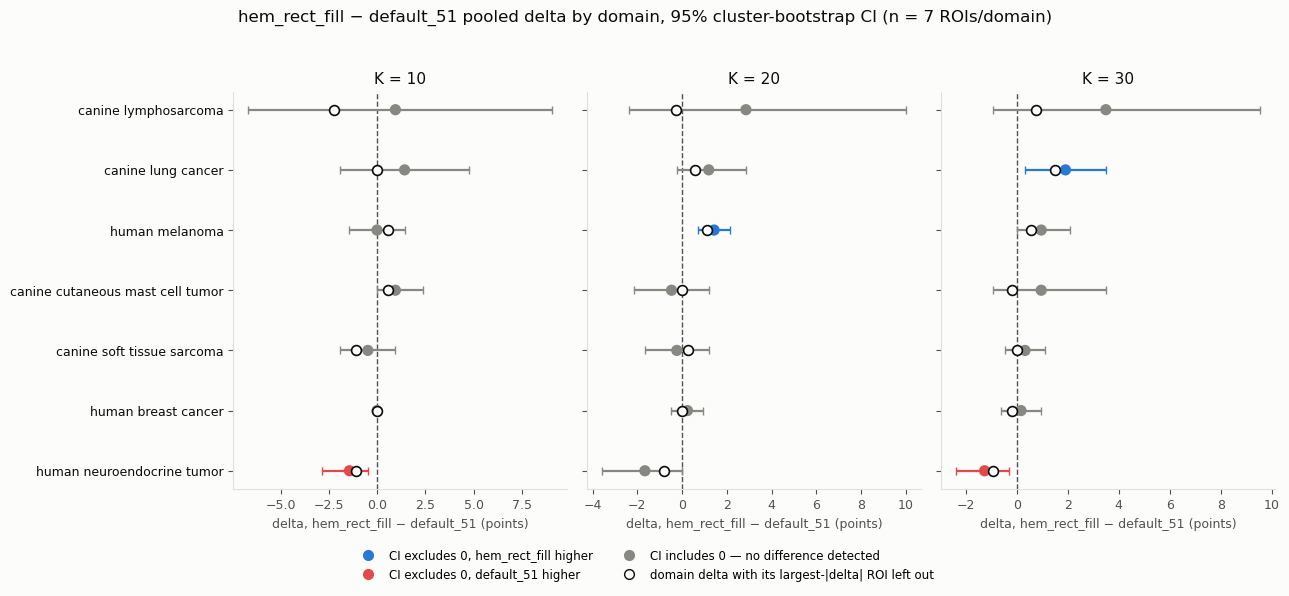

-> hemrectfill_by_domain_forest.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5.2), sharey=True, facecolor=SURFACE)
y = np.arange(len(ORDER))

for ax, k in zip(axes, BUDGETS):
    ax.set_facecolor(SURFACE)
    sub = DOMAIN_STATS[DOMAIN_STATS['K'] == k].set_index('domain').loc[ORDER]
    sens_k = SENS[SENS['K'] == k].set_index('domain').loc[ORDER]
    pooled_pts = sub['pooled_delta_precision'] * 100
    ci_lo_pts, ci_hi_pts = sub['ci_low'] * 100, sub['ci_high'] * 100
    colors = [BLUE if (row.ci_excludes_0 and row.pooled_delta_precision > 0) else RED if (row.ci_excludes_0 and row.pooled_delta_precision < 0) else GRAY for row in sub.itertuples()]

    xerr_lo = np.maximum(0, pooled_pts - ci_lo_pts)
    xerr_hi = np.maximum(0, ci_hi_pts - pooled_pts)
    for yi, (xv, elo, ehi, c) in enumerate(zip(pooled_pts, xerr_lo, xerr_hi, colors)):
        ax.errorbar([xv], [yi], xerr=[[elo], [ehi]], fmt='none', ecolor=c, elinewidth=1.6, capsize=3, zorder=2)
    ax.scatter(pooled_pts, y, c=colors, s=50, zorder=3)

    for yi, dom in enumerate(ORDER):
        full, rest = pooled_pts.loc[dom], sens_k.loc[dom, 'rest_pooled_pts']
        ax.plot([full, rest], [yi, yi], color=INK, linewidth=0.7, alpha=0.45, zorder=1)
    ax.scatter(sens_k['rest_pooled_pts'], y, facecolors=SURFACE, edgecolors=INK, s=50, linewidths=1.2, zorder=4)

    ax.axvline(0, color=MUTED, linewidth=1, linestyle='--', zorder=0)
    ax.set_title(f'K = {k}', fontsize=11, color=INK)
    ax.set_xlabel('delta, hem_rect_fill − default_51 (points)', fontsize=9, color=MUTED)
    ax.tick_params(colors=MUTED, labelsize=9)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color(GRID)

axes[0].set_yticks(y)
axes[0].set_yticklabels(ORDER, fontsize=9, color=INK)

legend_handles = [
    mlines.Line2D([], [], color=BLUE, marker='o', linestyle='none', markersize=7, label='CI excludes 0, hem_rect_fill higher'),
    mlines.Line2D([], [], color=RED, marker='o', linestyle='none', markersize=7, label='CI excludes 0, default_51 higher'),
    mlines.Line2D([], [], color=GRAY, marker='o', linestyle='none', markersize=7, label='CI includes 0 — no difference detected'),
    mlines.Line2D([], [], markerfacecolor=SURFACE, markeredgecolor=INK, marker='o', linestyle='none', markersize=7, label="domain delta with its largest-|delta| ROI left out"),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.09))
fig.suptitle('hem_rect_fill − default_51 pooled delta by domain, 95% cluster-bootstrap CI (n = 7 ROIs/domain)', fontsize=12, color=INK, y=1.03)
fig.tight_layout()
fig.savefig(FIG_PATHS['forest'], dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"-> {FIG_PATHS['forest']}")

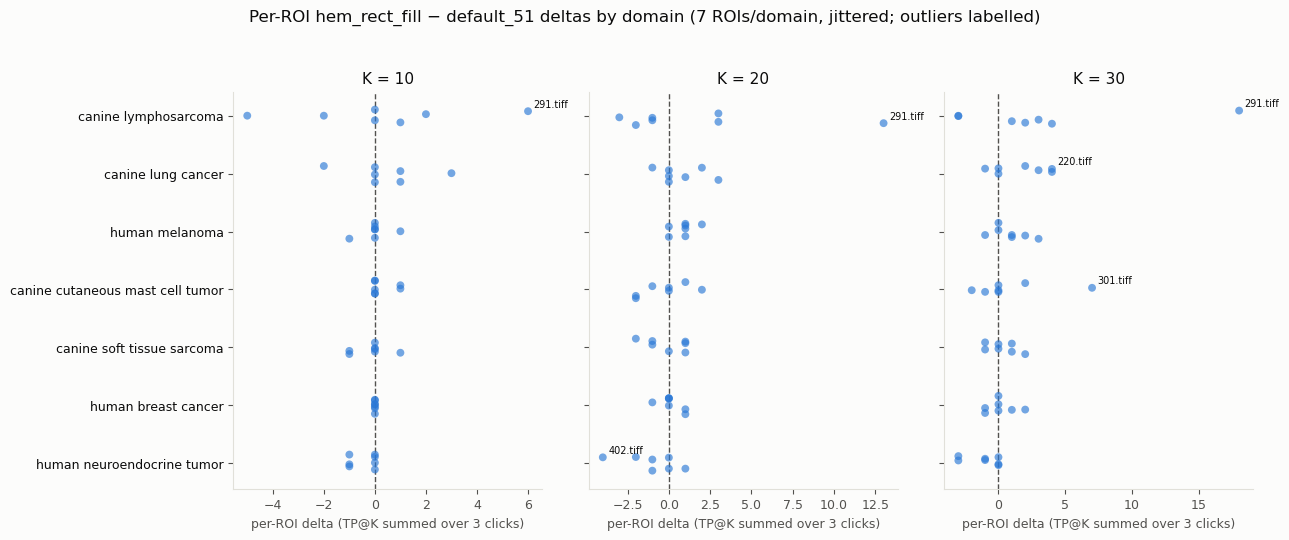

-> hemrectfill_by_domain_roi_strip.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5.2), sharey=True, facecolor=SURFACE)
rng_jitter = np.random.default_rng(1)

for ax, k in zip(axes, BUDGETS):
    ax.set_facecolor(SURFACE)
    sub = DELTA[DELTA['K'] == k]
    for yi, dom in enumerate(ORDER):
        vals = sub[sub['domain'] == dom].sort_values('file_name').reset_index(drop=True)
        jitter = rng_jitter.uniform(-0.16, 0.16, size=len(vals))
        ax.scatter(vals['delta_tp_sum'], yi + jitter, color=BLUE, alpha=0.65, s=32, zorder=2, edgecolors='none')
        top_i = vals['delta_tp_sum'].abs().idxmax()
        top = vals.loc[top_i]
        if abs(top['delta_tp_sum']) >= 4:  # only the outliers that are visually distinct get a direct label
            ax.annotate(top['file_name'], (top['delta_tp_sum'], yi + jitter[top_i]), xytext=(4, 3), textcoords='offset points', fontsize=7, color=INK)
    ax.axvline(0, color=MUTED, linewidth=1, linestyle='--', zorder=0)
    ax.set_title(f'K = {k}', fontsize=11, color=INK)
    ax.set_xlabel('per-ROI delta (TP@K summed over 3 clicks)', fontsize=9, color=MUTED)
    ax.tick_params(colors=MUTED, labelsize=9)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color(GRID)

axes[0].set_yticks(range(len(ORDER)))
axes[0].set_yticklabels(ORDER, fontsize=9, color=INK)
fig.suptitle('Per-ROI hem_rect_fill − default_51 deltas by domain (7 ROIs/domain, jittered; outliers labelled)', fontsize=12, color=INK, y=1.03)
fig.tight_layout()
fig.savefig(FIG_PATHS['strip'], dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"-> {FIG_PATHS['strip']}")

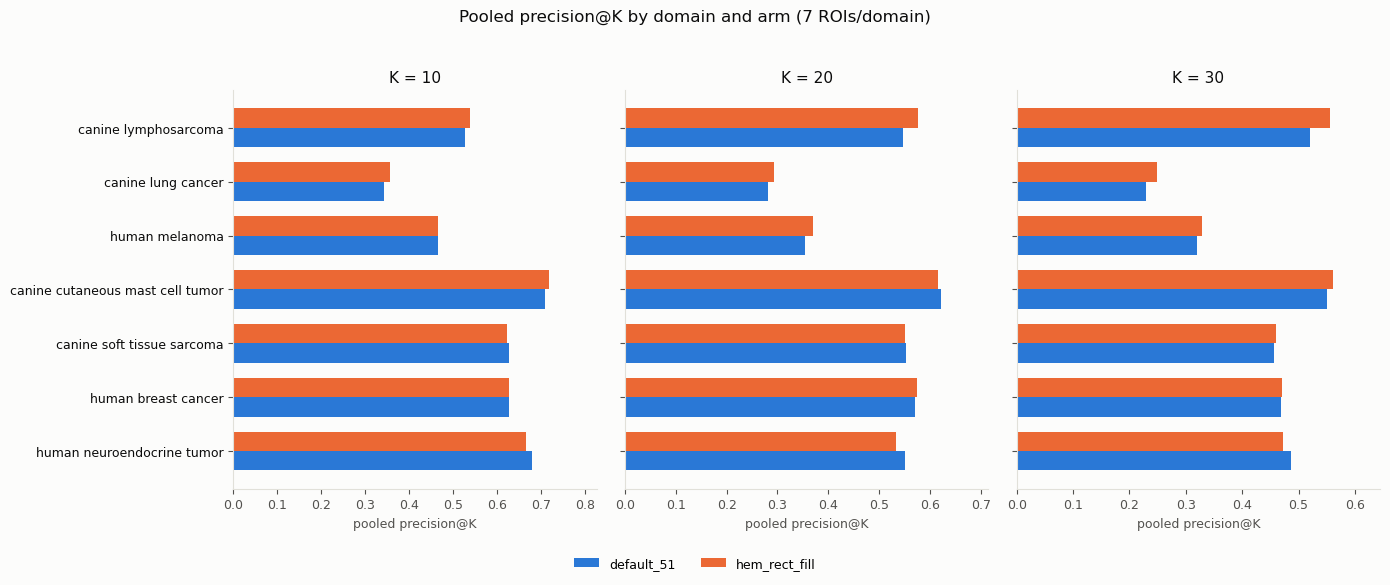

-> hemrectfill_by_domain_precision_bars.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), sharey=True, facecolor=SURFACE)
x = np.arange(len(ORDER))
width = 0.36

for ax, k in zip(axes, BUDGETS):
    ax.set_facecolor(SURFACE)
    d51 = DOMAIN_PREC[DOMAIN_PREC['condition'] == 'default_51'].set_index('domain').loc[ORDER, f'precision_at_{k}']
    hrf = DOMAIN_PREC[DOMAIN_PREC['condition'] == 'hem_rect_fill'].set_index('domain').loc[ORDER, f'precision_at_{k}']
    ax.barh(x - width / 2, d51, height=width, color=BLUE, label='default_51')
    ax.barh(x + width / 2, hrf, height=width, color=ORANGE, label='hem_rect_fill')
    ax.set_title(f'K = {k}', fontsize=11, color=INK)
    ax.set_xlabel('pooled precision@K', fontsize=9, color=MUTED)
    ax.set_xlim(0, max(d51.max(), hrf.max()) * 1.15)
    ax.tick_params(colors=MUTED, labelsize=9)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color(GRID)

axes[0].set_yticks(x)
axes[0].set_yticklabels(ORDER, fontsize=9, color=INK)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.07))
fig.suptitle('Pooled precision@K by domain and arm (7 ROIs/domain)', fontsize=12, color=INK, y=1.03)
fig.tight_layout()
fig.savefig(FIG_PATHS['bars'], dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"-> {FIG_PATHS['bars']}")

## Results

Every number below is printed by a cell above. "Points" are percentage points of precision. Every delta
is `hem_rect_fill - default_51`.

**Correctness gates (Cells 2-3, 5).** 294/294 `per_run` rows load with the expected shape; 7 domains x 7
ROIs (2 `original_14` + 5 `testing_35` each), confirmed structurally. `per_roi` and `delta_per_roi`,
independently recomputed here from `per_run.csv`, match the recorded `hemrectfill` files exactly on all
98 and 147 rows. `pair_stats()` reproduces the recorded all-49 `delta_stats.csv` bit-for-bit --
`pooled_delta_precision`, both CIs, W/L/T, `exact_p` and `holm_p` at every K -- before being applied to
the domain slices, which have no recorded reference to check against. This notebook's numbers are a
faithful slice of the already-verified `hemrectfill` run, not a new measurement.

**Pooled precision by domain and arm (Cell 6).** `canine lung cancer` and `human melanoma` are the
lowest-precision domains (`default_51` precision@30 0.23 and 0.32); `canine cutaneous mast cell tumor`
is the highest (0.55).

**Per-domain deltas (Cell 7), n = 7 ROIs per domain.** Holm is applied within each K, across the 7
domains (family size 7).

| domain | K=10 | K=20 | K=30 |
|---|---|---|---|
| canine cutaneous mast cell tumor | +0.95 [0.00, 2.38] | -0.48 [-2.14, 1.19] | +0.95 [-0.95, 3.49] |
| canine lung cancer | +1.43 [-1.90, 4.76] | +1.19 [-0.24, 2.86] | **+1.90 [0.32, 3.49]**, W4/L1/T2, p=.125, holm=.875 |
| canine lymphosarcoma | +0.95 [-6.67, 9.05] | +2.86 [-2.38, 10.00] | +3.49 [-0.95, 9.52] |
| canine soft tissue sarcoma | -0.48 [-1.90, 0.95] | -0.24 [-1.67, 1.19] | +0.32 [-0.48, 1.11] |
| human breast cancer | 0.00 [0.00, 0.00] (7/7 tied) | +0.24 [-0.48, 0.95] | +0.16 [-0.63, 0.95] |
| human melanoma | 0.00 [-1.43, 1.43] | **+1.43 [0.71, 2.14]**, W5/L0/T2, p=.062, holm=.438 | +0.95 [0.00, 2.06] |
| human neuroendocrine tumor | **-1.43 [-2.86, -0.48]**, W0/L3/T4, holm=1 | -1.67 [-3.57, 0.00] | **-1.27 [-2.38, -0.32]**, W0/L4/T3, p=.125, holm=.875 |

Bold = bootstrap CI excludes 0. **No cell survives Holm correction at the conventional 0.05 level** --
the best is `human melanoma` at K=20, holm p = 0.438. At n = 7 the sign-flip test's own resolution floor
with 5 nonzero ROIs (`human melanoma`, K=20) is p = 2/32 = 0.0625, which is what was observed -- the most
extreme result 5 same-signed, non-tied ROIs can produce. The domain breakdown does not resolve a
statistically supported domain effect at this sample size; every CI above is a wide bound, not a precise
estimate.

**Outlier sensitivity (Cell 8).** For 5 of 21 (domain, K) cells, the single ROI with the largest |delta|
either flips the domain's net sign when excluded, or its own delta exceeds the domain's total (the
remaining 6 ROIs net the opposite way):

- **`canine lymphosarcoma`, K=10 and K=20**: `291.tiff` alone (+6, then +13) is 3.0x and 1.08x the
  domain's own net (+2, +12) -- excluding it, the other 6 ROIs are net **negative** (-4, -1 TP). This is
  the same click already identified as driving the 49-ROI result; at the domain level it does not just
  inflate the effect, it **reverses the sign** of everything else in the domain at K=10/20. At K=30,
  `291.tiff` is a smaller majority share (82%) and the domain stays net positive (+4) without it, though
  much smaller than the reported +22.
- **`canine cutaneous mast cell tumor`, K=30**: `301.tiff` (+7) exceeds the domain's own net (+6); the
  other 6 ROIs are net -1 without it. A second, previously undocumented single-ROI-driven domain result.
- **`canine soft tissue sarcoma` K=20** and **`human breast cancer` K=30** also flip sign on removal, but
  both domains' total deltas are tiny (-1 and +1 TP) -- these are noise flipping sign around zero, not a
  masked effect.
- Neither domain that clears the raw (uncorrected) significance bar is outlier-driven this way:
  `canine lung cancer`'s K=30 top ROI is 33% of its domain sum, `human melanoma`'s K=20 top ROI is also
  33% -- both are broad-based among their 7 ROIs, unlike `canine lymphosarcoma`.

**The one consistent signal, unresolved.** `human neuroendocrine tumor` is negative at every K (-1.43,
-1.67, -1.27 pts) and its CI excludes 0 at K=10 and K=30. Unlike `canine lymphosarcoma`, this is not one
outlier: its top-|delta| ROI (`402.tiff`) is only 33-57% of the domain's own (negative) sum, and **zero
of its 7 ROIs move positive at K=10 or K=30** (W0/L3/T4 and W0/L4/T3) -- every ROI that moves, moves the
same way. It is the most internally consistent domain result in this breakdown. It still does not survive
Holm correction (best holm p = 0.875) and n = 7 is too small to resolve it either way -- but it is a
better candidate for a larger, targeted follow-up than any of the positive domains, all of which are
either statistically unresolved, outlier-driven, or both.

**Read together with [[hem-rect-fill-vs-default-at-chromatin-od]].** The domain breakdown does not
surface a clean, established win for `hem_rect_fill` in any domain -- it explains *why* the pooled
49-ROI K=30 result looked the way it did (a single `canine lymphosarcoma` click, `291.tiff` s0, rescuing
a catastrophic `default_51` failure) and additionally shows that mechanism recurring once more
(`canine cutaneous mast cell tumor`, `301.tiff`, K=30). The only pattern broader than a single click is a
small, statistically unresolved, consistently negative signal in `human neuroendocrine tumor`.